In [ ]:
!pip install ydata_profiling

In [ ]:
# ==========================================
# 1. SETARE MEDIU ȘI IMPORTURI
# ==========================================
# Concept: Biblioteci Python
# - pandas: Manipularea datelor tabelare (DataFrame).
# - seaborn/matplotlib: Vizualizarea datelor (grafice).
# - sklearn (Scikit-Learn): Biblioteca standard pentru Machine Learning (modele, metrici, preprocesare).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  # <--- IMPORT NOU PENTRU SCALING
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Configurare stil grafice
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# ==========================================
# 2. ÎNCĂRCARE ȘI CURĂȚARE DATELOR
# ==========================================
# Se presupune că fișierul 'Housing.csv' este în directorul curent.

df = pd.read_csv('/content/Housing.csv')

In [ ]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [ ]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
df.tail(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
535,2100000,3360,2,1,1,yes,no,no,no,no,1,no,unfurnished
536,1960000,3420,5,1,2,no,no,no,no,no,0,no,unfurnished
537,1890000,1700,3,1,2,yes,no,no,no,no,0,no,unfurnished
538,1890000,3649,2,1,1,yes,no,no,no,no,0,no,unfurnished
539,1855000,2990,2,1,1,no,no,no,no,no,1,no,unfurnished
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


<Axes: >

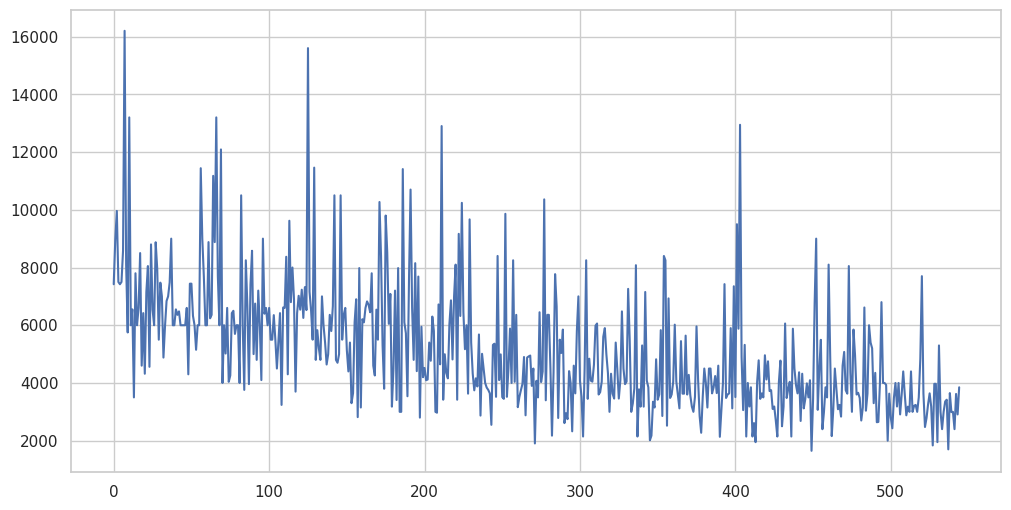

In [ ]:
df['area'].plot()

In [ ]:
# ==========================================
# GENERARE RAPORT AUTOMAT (YDATA PROFILING)
# ==========================================
import pandas as pd
from ydata_profiling import ProfileReport

# Asigură-te că DataFrame-ul 'df' este încărcat
# (Dacă nu e încărcat, decomentează linia de mai jos)
# df = pd.read_csv('/content/Housing.csv')

print("Se generează raportul... (poate dura câteva secunde)")

# 1. Configurarea raportului
# 'explorative=True' activează funcții avansate (text analysis, corelații detaliate)
profile = ProfileReport(
    df,
    title="Raport Analiză Prețuri Case",
    correlations={
        "pearson": {"calculate": True},
        "spearman": {"calculate": True},
        "kendall": {"calculate": True},
        "phi_k": {"calculate": True}, # Dezactivezi Phik dacă vrei doar clasic
    },
    explorative=True
)

# 2. Afișarea în Notebook (Varianta Iframe - cea mai stabilă)
# Aceasta afișează raportul direct aici, într-o fereastră cu scroll
profile.to_notebook_iframe()

# 3. Salvarea ca fișier HTML (Opțional, dar recomandat)
# Îți permite să descarci raportul și să îl trimiți altcuiva sau să îl deschizi în browser separat.
profile.to_file("Raport_Housing.html")

print("Gata! Raportul a fost salvat și ca 'Raport_Housing.html'.")

Se generează raportul... (poate dura câteva secunde)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 57.62it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Gata! Raportul a fost salvat și ca 'Raport_Housing.html'.


In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# Preprocesare: Convertim variabilele binare 'yes'/'no' în 1/0
# Concept: Binary Encoding
# Modelele matematice nu înțeleg text. Trebuie să transformăm "yes" în 1 și "no" în 0.

binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

print("Primele 5 rânduri după conversia text -> numeric (coloane binare):")
df.head()

Primele 5 rânduri după conversia text -> numeric (coloane binare):


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [ ]:
# Preprocesare: Label Encoding pentru variabila 'furnishingstatus'
# Concept: Label Encoding
# Variabila 'furnishingstatus' are mai multe categorii. Pentru a le folosi în model,
# le vom asigna valori numerice ordonate.

# Aplicăm Label Encoding pe 'furnishingstatus' cu o ordine specifică
furnishing_map = {
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
}
df['furnishingstatus'] = df['furnishingstatus'].map(furnishing_map)

print("Primele 5 rânduri după Label Encoding (coloana 'furnishingstatus'):")
df.head()

Primele 5 rânduri după Label Encoding (coloana 'furnishingstatus'):


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


In [ ]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,2



--- 3. EDA: Exploratory Data Analysis ---


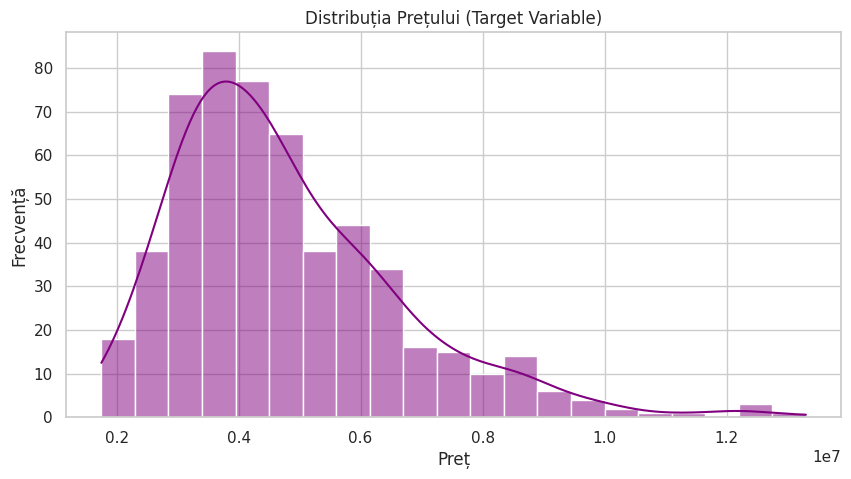

Interpetare: Dacă graficul are o coadă lungă spre dreapta, avem prețuri outlier mari.


In [ ]:
# ==========================================
# 3. EDA AVANSAT: DISTRIBUȚII ȘI RELAȚII
# ==========================================
print("\n--- 3. EDA: Exploratory Data Analysis ---")

# A. Distribuția variabilei țintă (Price)
# Concept: Distribuție și Skewness (Asimetrie)
# Vrem să vedem dacă prețurile urmează o distribuție normală (clopot Gauss).
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True, color='purple')
plt.title('Distribuția Prețului (Target Variable)')
plt.xlabel('Preț')
plt.ylabel('Frecvență')
plt.show()
print("Interpetare: Dacă graficul are o coadă lungă spre dreapta, avem prețuri outlier mari.")

/tmp/ipython-input-598193200.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='airconditioning', y='price', data=df, palette='Set2')


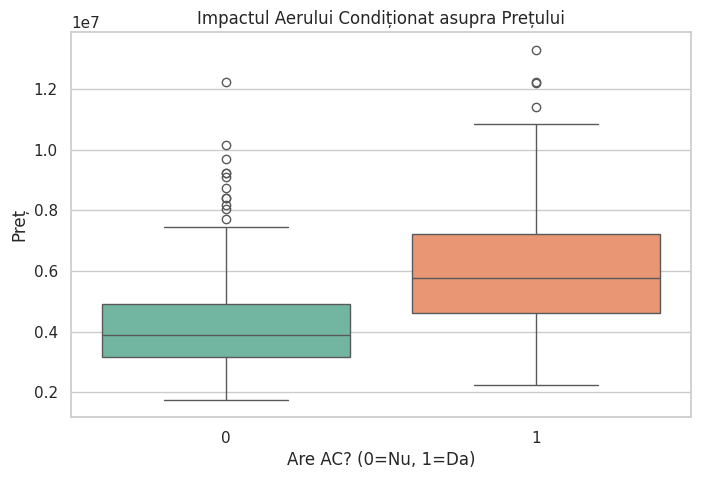

Interpretare Boxplot: Linia din mijlocul cutiei este mediana. Dacă cutia pentru '1' este mult mai sus decât '0', AC-ul crește valoarea casei.


In [ ]:
# B. Relația Categorial vs Numeric (Boxplot)
# Concept: Boxplot (Mustăți)
# Arată mediana și percentilele (25%, 75%). Este excelent pentru a compara grupuri.
# Întrebare: Casele cu Aer Condiționat sunt, în medie, mai scumpe?
if 'airconditioning' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='airconditioning', y='price', data=df, palette='Set2')
    plt.title('Impactul Aerului Condiționat asupra Prețului')
    plt.xlabel('Are AC? (0=Nu, 1=Da)')
    plt.ylabel('Preț')
    plt.show()
    print("Interpretare Boxplot: Linia din mijlocul cutiei este mediana. Dacă cutia pentru '1' este mult mai sus decât '0', AC-ul crește valoarea casei.")

In [ ]:
# ==========================================
# 4. PREGĂTIREA DATELOR PENTRU MODELARE
# ==========================================
# Selectăm toate coloanele ca variabile independente (features), exceptând 'price'
features = [col for col in df.columns if col != 'price']

X = df[features]
y = df['price']

# Împărțirea datelor (Train / Test)
# Concept: Train/Test Split
# Păstrăm 20% din date "ascunse" pentru a testa modelul la final pe date nevăzute.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

80% date de train - 20% date validation

Overfitting - învață datele pe de rost

random_state - reproduc experimentele cu aceiasi valoare

In [ ]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,6000,3,2,4,1,0,0,0,1,1,0,2
93,7200,3,2,1,1,0,1,0,1,3,0,1
335,3816,2,1,1,1,0,1,0,1,2,0,2
412,2610,3,1,2,1,0,1,0,0,0,1,0
471,3750,3,1,2,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1,0,0,0,1,0,0,0
106,5450,4,2,1,1,0,1,0,1,0,1,1
270,4500,3,2,3,1,0,0,1,0,1,0,2
435,4040,2,1,1,1,0,0,0,0,0,0,0


In [ ]:
y_train

,price
46,7525000
93,6300000
335,3920000
412,3430000
471,3010000
...,...
71,6755000
106,6160000
270,4340000
435,3290000


In [ ]:
X_test

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
316,5900,4,2,2,0,0,1,0,0,1,0,0
77,6500,3,2,3,1,0,0,0,1,0,1,2
360,4040,2,1,1,1,0,0,0,0,0,0,1
90,5000,3,1,2,1,0,0,0,1,0,0,1
493,3960,3,1,1,1,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,1,0,1,0,0,2,0,1
357,6930,4,1,2,0,0,0,0,0,1,0,2
39,6000,4,2,4,1,0,0,0,1,1,0,1
54,6000,3,2,2,1,1,0,0,1,1,0,1


In [ ]:
df['area'].mean(), df['area'].std()

(np.float64(5150.54128440367), 2170.141022508803)

In [ ]:
# ==========================================
# 5. FEATURE SCALING (NOU!)
# ==========================================
print("\n--- 5. Feature Scaling (Standardization) ---")
# Concept: Standardizare (Z-score normalization)
# Formula: z = (x - mean) / std_dev
# De ce?
# 'area' are valori de ordinul miilor (ex: 5000 mp), iar 'bedrooms' are valori mici (ex: 3).
# Fără scalare, modelul ar putea crede că 'area' este mult mai importantă doar pentru că are numere mai mari,
# sau optimizarea (Gradient Descent) ar dura mult mai mult.
# Aducem totul la Media = 0 și Deviația Standard = 1.

scaler = StandardScaler()

# ATENȚIE: Facem .fit doar pe X_train pentru a evita "Data Leakage" (nu vrem ca media din test să influențeze antrenarea).
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Doar transform pe test


--- 5. Feature Scaling (Standardization) ---


In [ ]:
X_train_scaled

array([[ 0.38416819,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032,  1.40940148],
       [ 0.9291807 ,  0.05527092,  1.53917323, ...,  2.70998729,
        -0.55262032,  0.07931697],
       [-0.60775457, -1.28351359, -0.5579503 , ...,  1.53897197,
        -0.55262032,  1.40940148],
       ...,
       [-0.29709744,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032,  1.40940148],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.80305867,
        -0.55262032, -1.25076755],
       [ 0.15707965,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032,  0.07931697]])

In [ ]:
X.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')

In [ ]:
# Transformăm înapoi în DataFrame pentru a păstra numele coloanelor (pentru vizualizare)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

In [ ]:
print("Exemplu date înainte de scalare (Area):")
print(X_train['area'].head(3).values)
print("\nExemplu date DUPĂ scalare (Area):")
print(X_train_scaled_df['area'].head(3).values)
print("(Observați cum valorile sunt acum mici, centrate în jurul lui 0)")

Exemplu date înainte de scalare (Area):
[6000 7200 3816]

Exemplu date DUPĂ scalare (Area):
[ 0.38416819  0.9291807  -0.60775457]
(Observați cum valorile sunt acum mici, centrate în jurul lui 0)


In [ ]:
?LinearRegression

In [ ]:
??LinearRegression

In [ ]:
# ==========================================
# 6. REGRESIE LINIARĂ MULTIPLĂ PE DATE SCALATE
# ==========================================
model = LinearRegression()

In [ ]:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# Predicții pe test/validare
y_pred = model.predict(X_test_scaled)

In [ ]:
y_pred

array([5203691.70963177, 7257004.02115475, 3062828.59668172,
       4559591.65374424, 3332932.30559783, 3563080.67918996,
       5645466.3121997 , 6413979.66873635, 2755831.54819001,
       2668938.6607523 , 9570600.29915351, 2827431.50860062,
       3195686.25834091, 3352263.99438472, 3713879.49996132,
       5301088.2443575 , 2987920.26669682, 4810799.8212371 ,
       4383031.70489929, 3525092.18938646, 5796259.50068013,
       5840000.702993  , 2760214.60864101, 4762590.14920608,
       5204755.73895204, 7515542.71619022, 3254681.68956383,
       5236164.45964445, 8178523.1682028 , 3434166.1567565 ,
       6443921.58767582, 3346004.77919185, 6742324.74004132,
       4154936.84088665, 3589152.47491253, 5788125.92515323,
       4768370.18154077, 4391684.04193173, 3217657.04549936,
       4638196.61928879, 4522160.27786713, 3541284.06127246,
       7238136.1194117 , 4021515.68926614, 3701978.76822756,
       4298879.55563098, 6705004.0206061 , 3993466.52296897,
       3798185.05328058,

In [ ]:
# Evaluare
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

In [ ]:
print(f"\n--- Rezultate Model ---")
print(f"R2 Score: {r2:.4f}")
print(f"Acest scor arată cât la sută din variația prețului este explicată de caracteristicile casei.")


--- Rezultate Model ---
R2 Score: 0.6495
Acest scor arată cât la sută din variația prețului este explicată de caracteristicile casei.


In [ ]:
model.coef_

array([519288.13010471,  58690.91849754, 523153.38284253, 348177.1136099 ,
       128115.92797751,  89357.64620755, 188462.04856579, 150570.02827934,
       362446.18646599, 192786.98589143, 266661.04914928, 158183.27016874])


--- Interpretabilitate: Ce contează cel mai mult? ---
             Feature    Coefficient
2          bathrooms  523153.382843
0               area  519288.130105
8    airconditioning  362446.186466
3            stories  348177.113610
10          prefarea  266661.049149
9            parking  192786.985891
6           basement  188462.048566
11  furnishingstatus  158183.270169
7    hotwaterheating  150570.028279
4           mainroad  128115.927978
5          guestroom   89357.646208
1           bedrooms   58690.918498


/tmp/ipython-input-4107876354.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance, palette='viridis')


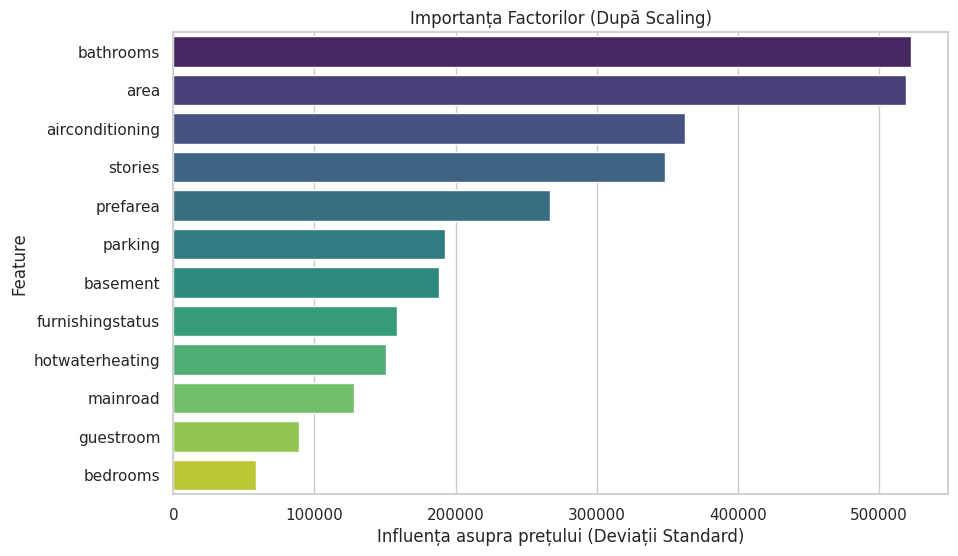


CONCLUZIE FINALĂ:
1. Barele cele mai lungi (pozitive) sunt caracteristicile care cresc cel mai mult prețul.
2. Datorită Scalării, putem spune sigur că dacă 'area' are coeficientul 0.4 și 'bathrooms' are 0.3,
   suprafața este un factor ușor mai important, lucru imposibil de zis fără scalare.



In [ ]:
# ==========================================
# 7. INTERPRETAREA COEFICIENȚILOR (FEATURE IMPORTANCE)
# ==========================================
print("\n--- Interpretabilitate: Ce contează cel mai mult? ---")
# Concept: Coeficienți Standardizați
# Deoarece am făcut Scaling, acum putem compara coeficienții direct!
# Un coeficient mai mare înseamnă o influență mai mare asupra prețului.

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(importance)

# Vizualizare Importanță
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=importance, palette='viridis')
plt.title('Importanța Factorilor (După Scaling)')
plt.xlabel('Influența asupra prețului (Deviații Standard)')
plt.show()

print("""
CONCLUZIE FINALĂ:
1. Barele cele mai lungi (pozitive) sunt caracteristicile care cresc cel mai mult prețul.
2. Datorită Scalării, putem spune sigur că dacă 'area' are coeficientul 0.4 și 'bathrooms' are 0.3,
   suprafața este un factor ușor mai important, lucru imposibil de zis fără scalare.
""")

In [ ]:
# ==========================================
# 8. SISTEM DE PREDICȚIE (INFERENCE)
# ==========================================

def prezice_pret_casa(new_data_dict):
    """
    Funcție care primește un dicționar cu detaliile casei,
    scalează datele și returnează prețul prezis.
    """
    # 1. Creăm un DataFrame din datele noi
    df_new = pd.DataFrame([new_data_dict])

    # 2. Preprocesare: Conversie text -> numere (exact ca la antrenare)
    # Aplicăm maparea pe df_new, nu pe df global
    binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
    for col in binary_cols:
        if col in df_new.columns:
            df_new[col] = df_new[col].map({'yes': 1, 'no': 0})

    furnishing_map = {
        'unfurnished': 0,
        'semi-furnished': 1,
        'furnished': 2
    }
    if 'furnishingstatus' in df_new.columns:
        df_new['furnishingstatus'] = df_new['furnishingstatus'].map(furnishing_map)

    # 3. Asigurăm ordinea corectă a coloanelor (trebuie să fie identică cu cea de la antrenare!)
    # Variabila 'features' a fost definită în pasul 4 al codului anterior
    # Verificăm că toate coloanele din 'features' sunt prezente în df_new
    # Dacă lipsesc, adăugăm coloane cu valoarea implicită 0
    for f in features:
        if f not in df_new.columns:
            df_new[f] = 0 # Sau o altă valoare implicită corespunzătoare
    df_new = df_new[features] # Reordonăm coloanele

    # 4. SCALING: Aplicăm transformarea standard
    # ATENȚIE: Folosim 'scaler.transform', NU 'fit_transform'.
    # Trebuie să folosim media și deviația învățate din datele de antrenament.
    df_new_scaled = scaler.transform(df_new)

    # 5. Predicția
    predicted_price = model.predict(df_new_scaled)

    return predicted_price[0]

In [ ]:
# --- EXEMPLU DE FOLOSIRE ---

# Definim o casă nouă (date brute, așa cum le-ar introduce un utilizator)
casa_mea = {
    'area': 7500,
    'bedrooms': 3,
    'bathrooms': 2,
    'stories': 2,
    'mainroad': 'yes',
    'guestroom': 'no',
    'basement': 'yes',
    'hotwaterheating': 'no',
    'airconditioning': 'yes',
    'parking': 2,
    'prefarea': 'yes',
    'furnishingstatus': 'furnished'
}

# Apelăm funcția
pret_estimat = prezice_pret_casa(casa_mea)

print(f"--- Rezultat Predicție ---")
print(f"Detalii casă: {casa_mea}")
print(f"Preț estimat de model: ${pret_estimat:,.2f}")

--- Rezultat Predicție ---
Detalii casă: {'area': 7500, 'bedrooms': 3, 'bathrooms': 2, 'stories': 2, 'mainroad': 'yes', 'guestroom': 'no', 'basement': 'yes', 'hotwaterheating': 'no', 'airconditioning': 'yes', 'parking': 2, 'prefarea': 'yes', 'furnishingstatus': 'furnished'}
Preț estimat de model: $7,931,302.44


In [ ]:
# ==========================================
# 9. INTERFAȚĂ GRAFICĂ (WIDGETS)
# ==========================================
import ipywidgets as widgets
from IPython.display import display, clear_output

print("--- Configurator Preț Casă ---")

# 1. Definim Elementele de Input (Widgets)

# Slider pentru Suprafață (Area)
w_area = widgets.IntSlider(
    value=4000,
    min=1500,
    max=16000,
    step=100,
    description='Suprafață (mp):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

# Slider pentru Dormitoare
w_bedrooms = widgets.IntSlider(
    value=3,
    min=1,
    max=6,
    step=1,
    description='Dormitoare:',
    style={'description_width': 'initial'}
)

# Slider pentru Băi
w_bathrooms = widgets.IntSlider(
    value=1,
    min=1,
    max=4,
    step=1,
    description='Băi:',
    style={'description_width': 'initial'}
)

# Slider pentru Etaje
w_stories = widgets.IntSlider(
    value=2,
    min=1,
    max=4,
    step=1,
    description='Etaje:',
    style={'description_width': 'initial'}
)

# Dropdown pentru Drum Principal
w_mainroad = widgets.Dropdown(
    options=['yes', 'no'],
    value='yes',
    description='Drum Principal:',
    style={'description_width': 'initial'}
)

# Dropdown pentru Cameră de Oaspeți
w_guestroom = widgets.Dropdown(
    options=['yes', 'no'],
    value='no',
    description='Cameră Oaspeți:',
    style={'description_width': 'initial'}
)

# Dropdown pentru Subsol
w_basement = widgets.Dropdown(
    options=['yes', 'no'],
    value='no',
    description='Subsol:',
    style={'description_width': 'initial'}
)

# Dropdown pentru Încălzire Apă Caldă
w_hotwaterheating = widgets.Dropdown(
    options=['yes', 'no'],
    value='no',
    description='Încălzire Apă Caldă:',
    style={'description_width': 'initial'}
)

# Dropdown pentru Aer Condiționat
w_airconditioning = widgets.Dropdown(
    options=['yes', 'no'],
    value='no',
    description='Aer Condiționat:',
    style={'description_width': 'initial'}
)

# Slider pentru Locuri de Parcare
w_parking = widgets.IntSlider(
    value=0,
    min=0,
    max=3,
    step=1,
    description='Locuri Parcare:',
    style={'description_width': 'initial'}
)

# Dropdown pentru Zonă Preferată
w_prefarea = widgets.Dropdown(
    options=['yes', 'no'],
    value='no',
    description='Zonă Preferată:',
    style={'description_width': 'initial'}
)

# Dropdown pentru Status Mobilier
w_furnishingstatus = widgets.Dropdown(
    options=['unfurnished', 'semi-furnished', 'furnished'],
    value='unfurnished',
    description='Status Mobilier:',
    style={'description_width': 'initial'}
)

# Buton de Calcul
btn_calc = widgets.Button(
    description='Calculează Preț',
    button_style='success', # 'success', 'info', 'warning', 'danger' or ''
    icon='calculator',
    layout=widgets.Layout(width='30%', margin='20px 0px 0px 0px')
)

# Zona de Output (unde apare rezultatul)
out_result = widgets.Output()

# 2. Logica Butonului (Ce se întâmplă când dai click)
def on_btn_click(b):
    with out_result:
        clear_output() # Șterge rezultatul anterior

        # Colectăm datele din widgets
        input_data = {
            'area': w_area.value,
            'bedrooms': w_bedrooms.value,
            'bathrooms': w_bathrooms.value,
            'stories': w_stories.value,
            'mainroad': w_mainroad.value,
            'guestroom': w_guestroom.value,
            'basement': w_basement.value,
            'hotwaterheating': w_hotwaterheating.value,
            'airconditioning': w_airconditioning.value,
            'parking': w_parking.value,
            'prefarea': w_prefarea.value,
            'furnishingstatus': w_furnishingstatus.value
        }

        # Facem predicția folosind funcția definită anterior
        # (Asigură-te că ai rulat celula cu funcția 'prezice_pret_casa' înainte!)
        try:
            pret = prezice_pret_casa(input_data)

            # Afișare stilizată
            print(f"\n🏠 Configurație selectată:")
            print(f"   - Suprafață: {input_data['area']} mp, Dormitoare: {input_data['bedrooms']}, Băi: {input_data['bathrooms']}")
            print(f"   - AC: {input_data['airconditioning']}, Mobilier: {input_data['furnishingstatus']}")
            print("-" * 30)
            print(f"💰 PREȚ ESTIMAT: ${pret:,.2f}")
            print("-" * 30)

        except Exception as e:
            print(f"Eroare la predicție: {e}")

# Conectăm butonul la funcție
btn_calc.on_click(on_btn_click)

# 3. Afișarea Interfeței (Layout)
ui = widgets.VBox([
    widgets.HTML("<h3>Introduceți detaliile casei:</h3>"),
    w_area,
    w_bedrooms,
    w_bathrooms,
    w_stories,
    w_mainroad,
    w_guestroom,
    w_basement,
    w_hotwaterheating,
    w_airconditioning,
    w_parking,
    w_prefarea,
    w_furnishingstatus,
    btn_calc,
    out_result
])

display(ui)

--- Configurator Preț Casă ---


In [ ]:
# ==========================================
# 10. SALVAREA ȘI ÎNCĂRCAREA MODELULUI
# ==========================================
import joblib

# Nume de fișiere pentru salvare
model_filename = 'linear_regression_model.pkl'
scaler_filename = 'standard_scaler.pkl'

print("--- Salvare Model și Scaler ---")
# Salvăm modelul antrenat și scaler-ul
joblib.dump(model, model_filename)
joblib.dump(scaler, scaler_filename)
print(f"Modelul a fost salvat ca '{model_filename}'")
print(f"Scaler-ul a fost salvat ca '{scaler_filename}'")

--- Salvare Model și Scaler ---
Modelul a fost salvat ca 'linear_regression_model.pkl'
Scaler-ul a fost salvat ca 'standard_scaler.pkl'


In [ ]:
print("\n--- Încărcare Model și Scaler ---")
# Încărcăm modelul și scaler-ul salvat
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)
print("Modelul și scaler-ul au fost încărcate cu succes.")


--- Încărcare Model și Scaler ---
Modelul și scaler-ul au fost încărcate cu succes.


In [ ]:
print("\n--- Testare Model Încărcat ---")
# Folosim modelul și scaler-ul încărcat pentru o predicție
# Reutilizăm 'casa_mea' definită anterior
casa_mea = {
    'area': 7500,
    'bedrooms': 3,
    'bathrooms': 2,
    'stories': 2,
    'mainroad': 'yes',
    'guestroom': 'no',
    'basement': 'yes',
    'hotwaterheating': 'no',
    'airconditioning': 'yes',
    'parking': 2,
    'prefarea': 'yes',
    'furnishingstatus': 'furnished'
}

# Asigurăm aceleași preprocesări ca în funcția prezice_pret_casa
df_test_loaded = pd.DataFrame([casa_mea])


--- Testare Model Încărcat ---


In [ ]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    if col in df_test_loaded.columns:
        df_test_loaded[col] = df_test_loaded[col].map({'yes': 1, 'no': 0})

furnishing_map = {
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
}
if 'furnishingstatus' in df_test_loaded.columns:
    df_test_loaded['furnishingstatus'] = df_test_loaded['furnishingstatus'].map(furnishing_map)

In [ ]:
# Scalăm datele cu scaler-ul încărcat
df_test_scaled_loaded = loaded_scaler.transform(df_test_loaded)

# Facem predicția cu modelul încărcat
predicted_price_loaded = loaded_model.predict(df_test_scaled_loaded)

print(f"Preț estimat de modelul încărcat (pentru casa_mea): ${predicted_price_loaded[0]:,.2f}")
print("Acest lucru confirmă că modelul și scaler-ul pot fi salvate și reutilizate.")

Preț estimat de modelul încărcat (pentru casa_mea): $7,931,302.44
Acest lucru confirmă că modelul și scaler-ul pot fi salvate și reutilizate.
